### Importing Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import ttest_ind
import scipy.stats as stats

# Warning handling
import warnings
warnings.filterwarnings('ignore')

from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [2]:
DB_HOST = "127.0.0.1"
DB_PORT = 5432
DB_NAME = "vendor_performance"
DB_USER = "postgres"

DB_PASSWORD = getpass("PostgreSQL password: ")

In [3]:
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

engine = create_engine(
    connection_url,
    connect_args={
        "options": "-csearch_path=vendor,public"
    }
)

In [4]:
with engine.connect() as conn:
    result = conn.execute(
        text("""
            SELECT
                current_database() AS database_name,
                current_user AS user_name,
                current_schema() AS current_schema;
        """)
    )

    print(result.mappings().one())

{'database_name': 'vendor_performance', 'user_name': 'postgres', 'current_schema': 'vendor'}


# Phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA)

- Trước đó, đã xem xét các bảng khác nhau trong cơ sở dữ liệu nhằm xác định những biến quan trọng, hiểu mối quan hệ giữa các biến và quyết định những biến nào nên được đưa vào phân tích cuối cùng.

- Trong giai đoạn EDA này, chúng ta sẽ phân tích bảng dữ liệu tổng hợp để tìm hiểu **phân phối của từng cột**:
  - Hiểu rõ các mẫu và xu hướng trong dữ liệu
  - Phát hiện các giá trị bất thường (`anomalies`)
  - Kiểm tra tính nhất quán và chất lượng dữ liệu
  - Đảm bảo dữ liệu đủ tin cậy trước khi tiến hành các bước phân tích tiếp theo

In [10]:
# Load aggregated data for EDA

df = pd.read_sql_query(
    "SELECT * FROM vendor.vendor_sales_summary",
    engine
)

print("Data loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Data loaded successfully!
Shape: (10648, 18)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40


In [11]:
# Summary statistics for numerical columns

summary_stats = vendor_sales_summary.describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,10640.705203,18700.404409,2.00,3943.5000,7153.000,9552.0000,173357.00
Brand,10648.0,18054.503193,12643.196784,58.00,5816.5000,18776.500,25521.2500,90631.00
PurchasePrice,10648.0,24.402095,109.483355,0.36,6.8400,10.450,19.4700,5681.81
ActualPrice,10648.0,35.671184,148.534066,0.49,10.9900,15.990,28.9900,7499.99
Volume,10648.0,847.883922,665.354103,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10648.0,3145.159936,11113.367455,1.00,36.0000,261.000,1981.2500,337660.00
TotalPurchaseDollars,10648.0,30138.163064,123277.154715,0.71,452.8575,3646.725,20764.1700,3811251.60
TotalSalesQuantity,10648.0,3081.902047,10971.073340,0.00,33.0000,260.500,1934.2500,334939.00
TotalSalesDollars,10648.0,42302.921643,167947.264974,0.00,728.2750,5285.915,28414.0500,5101919.51
TotalSalesPrice,10648.0,18813.647626,45018.406384,0.00,288.8300,2841.775,16080.2700,672819.31


In [12]:
# Mode for each numerical column
mode_values = df.mode().iloc[0]
print("\nMode Values:\n\n", mode_values)



Mode Values:

 VendorNumber                            4425.0
VendorName               MARTIGNETTI COMPANIES
Brand                                       58
Description               Bacardi Superior Rum
PurchasePrice                             6.53
ActualPrice                               9.99
Volume                                   750.0
TotalPurchaseQuantity                     12.0
TotalPurchaseDollars                     95.28
TotalSalesQuantity                        12.0
TotalSalesDollars                          0.0
TotalSalesPrice                            0.0
TotalExciseTax                             0.0
FreightCost                          144929.24
GrossProfit                                0.0
ProfitMargin                               0.0
StockTurnover                              1.0
SalesToPurchaseRatio                      1.48
Name: 0, dtype: object


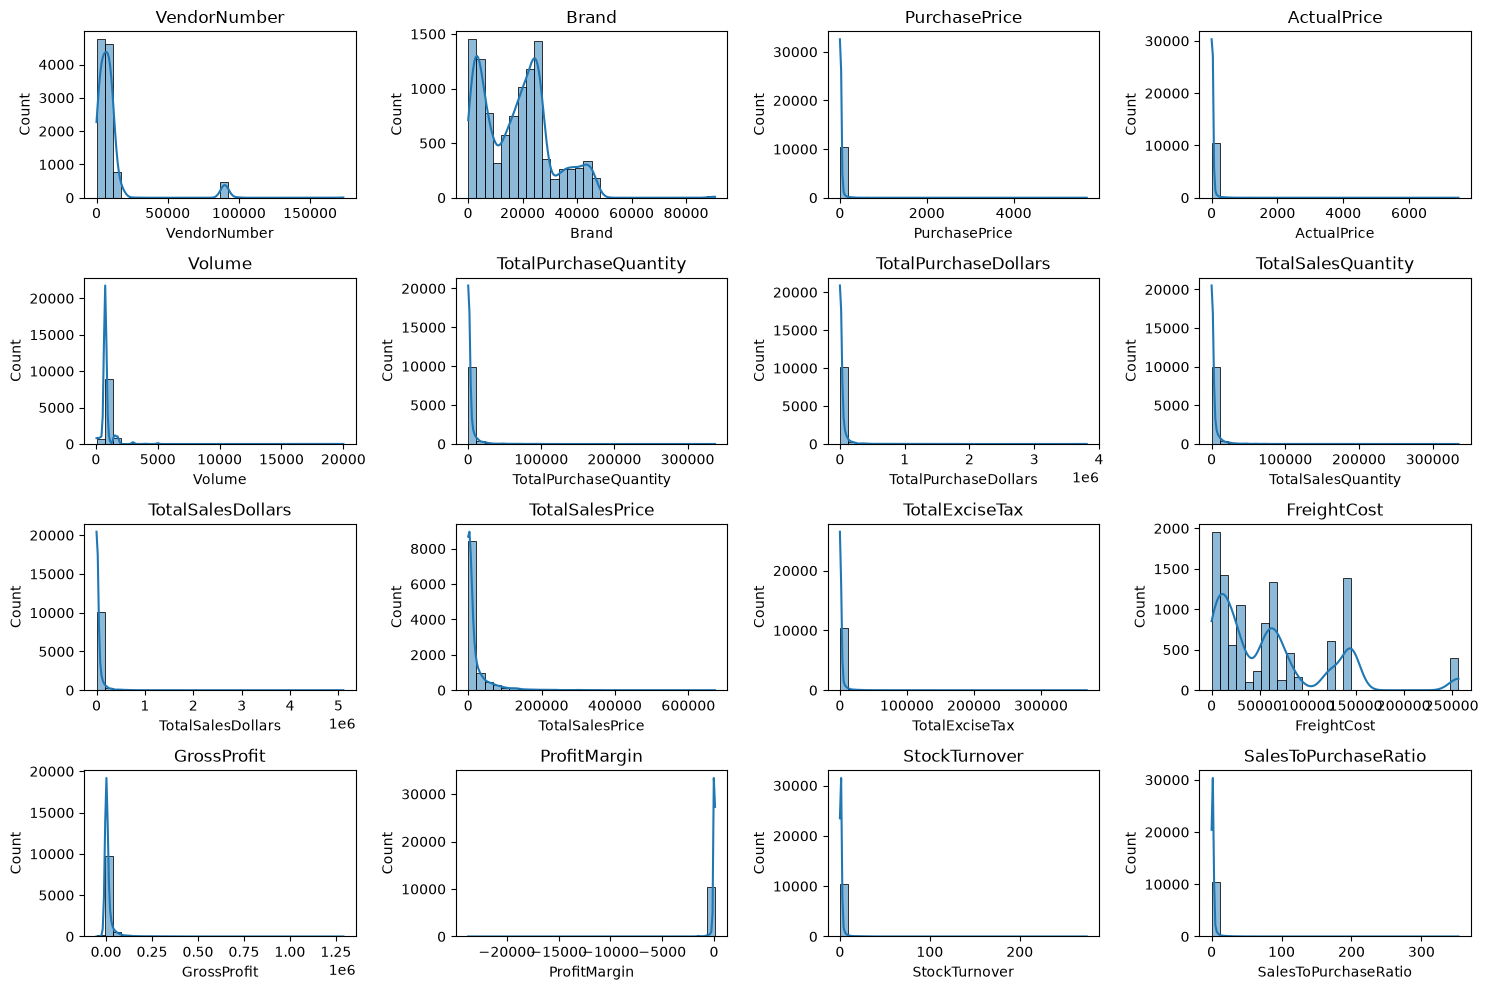

In [13]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

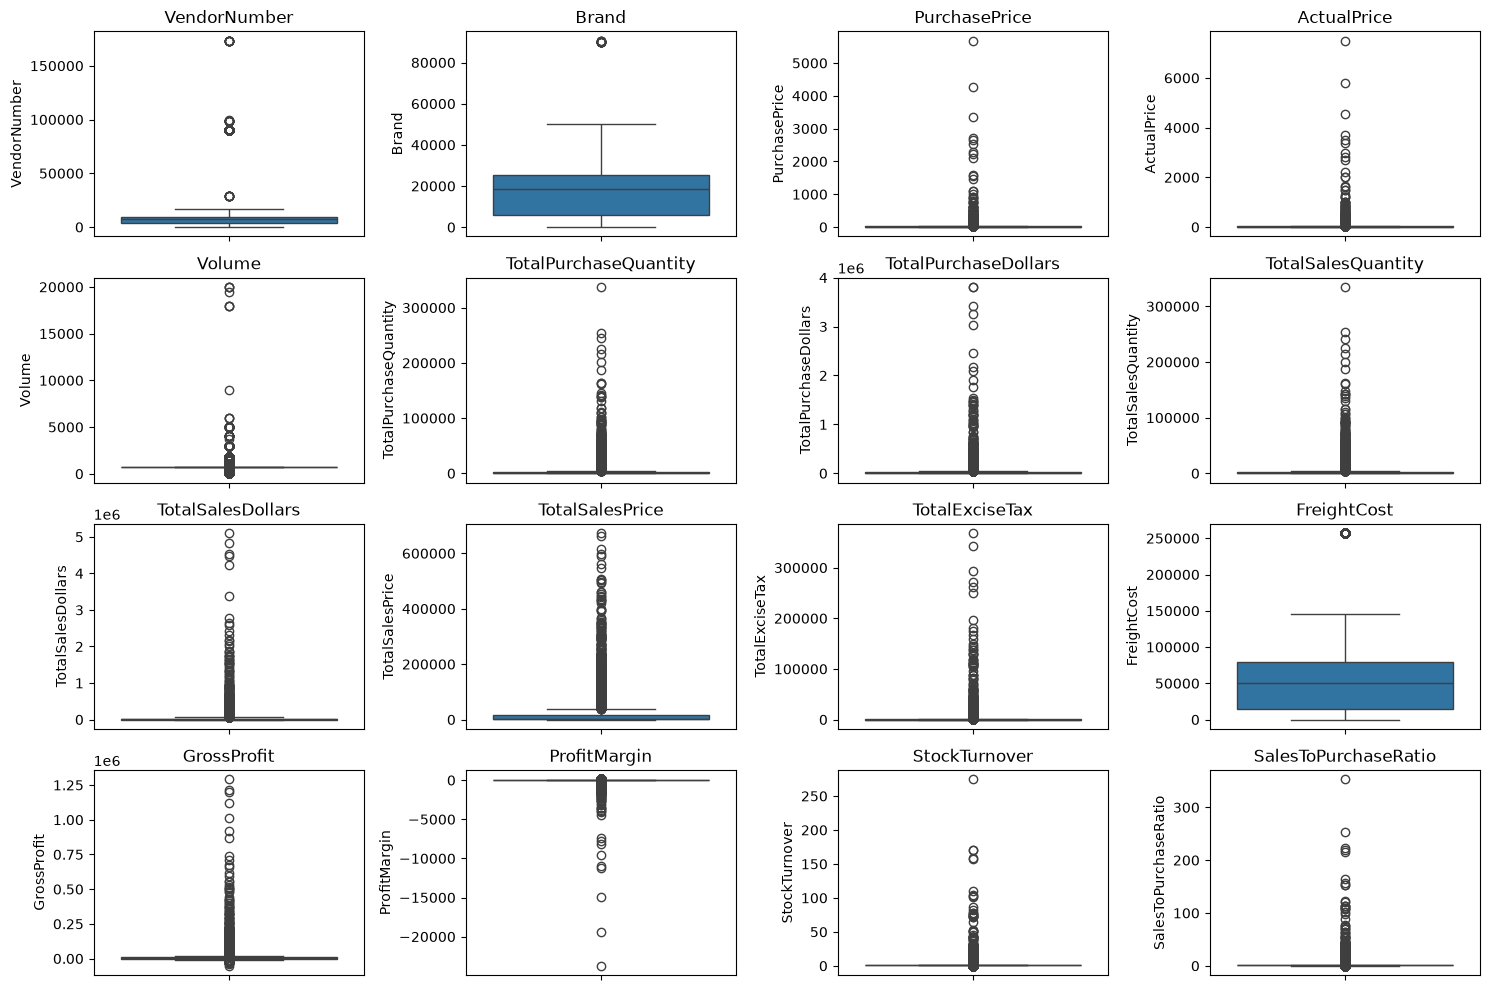

In [14]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Nhận định từ thống kê mô tả

### Giá trị âm và bằng 0

- **Gross Profit (Lợi nhuận gộp):** Giá trị nhỏ nhất là **-52,002.78**, cho thấy tồn tại các trường hợp bị lỗ. Một số sản phẩm hoặc giao dịch có thể được bán dưới giá vốn do chi phí cao hoặc do áp dụng mức chiết khấu khiến giá bán thấp hơn giá mua.

- **Profit Margin (Biên lợi nhuận):** Giá trị nhỏ nhất là **-∞**, cho thấy có những trường hợp phép tính biên lợi nhuận gặp vấn đề, thường xảy ra khi doanh thu bằng 0 trong khi vẫn phát sinh chi phí.

- **Total Sales Quantity & Total Sales Dollars:** Giá trị nhỏ nhất bằng **0**, nghĩa là có một số sản phẩm đã được mua nhưng chưa phát sinh bán hàng. Đây có thể là các sản phẩm **bán chậm (slow-moving)** hoặc hàng tồn kho lâu ngày.

### Các giá trị ngoại lệ thể hiện qua độ lệch chuẩn cao

- **Purchase Price & Actual Price:** Giá trị lớn nhất lần lượt là **5,681.81** và **7,499.99**, cao hơn đáng kể so với giá trị trung bình tương ứng là **24.39** và **35.64**. Điều này cho thấy dữ liệu có thể chứa một số sản phẩm thuộc phân khúc giá cao hoặc các giá trị ngoại lệ cần được kiểm tra thêm.

- **Freight Cost (Chi phí vận chuyển):** Có mức biến động rất lớn, từ **0.09** đến **257,032.07**. Điều này có thể phản ánh sự khác biệt đáng kể về quy mô đơn hàng, khoảng cách vận chuyển, hình thức vận chuyển hoặc khả năng tồn tại sự thiếu hiệu quả trong hoạt động logistics.

- **Stock Turnover (Vòng quay hàng tồn kho):** Giá trị dao động từ **0** đến **274.5**, cho thấy có những sản phẩm được bán rất nhanh trong khi một số sản phẩm gần như không phát sinh bán hàng.

  Giá trị `Stock Turnover > 1` cho thấy **số lượng bán ra lớn hơn số lượng mua vào trong giai đoạn được phân tích**. Điều này có thể xảy ra do doanh nghiệp sử dụng lượng hàng tồn kho từ các kỳ trước để đáp ứng nhu cầu bán hàng.

In [15]:
# Filter the data by removing inconsistencies

df = pd.read_sql_query(
    """
    SELECT *
    FROM vendor.vendor_sales_summary
    WHERE "GrossProfit" > 0
      AND "ProfitMargin" > 0
      AND "TotalSalesQuantity" > 0
    """,
    engine
)

df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8536,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5,15.95,10.96,0.55,27100.41,13.31,83.45,2.50,6.04
8537,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,22.33,28.06
8538,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,1.00,1.34
8539,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.97,72.00,97.47


In [16]:
df.shape

(8541, 18)

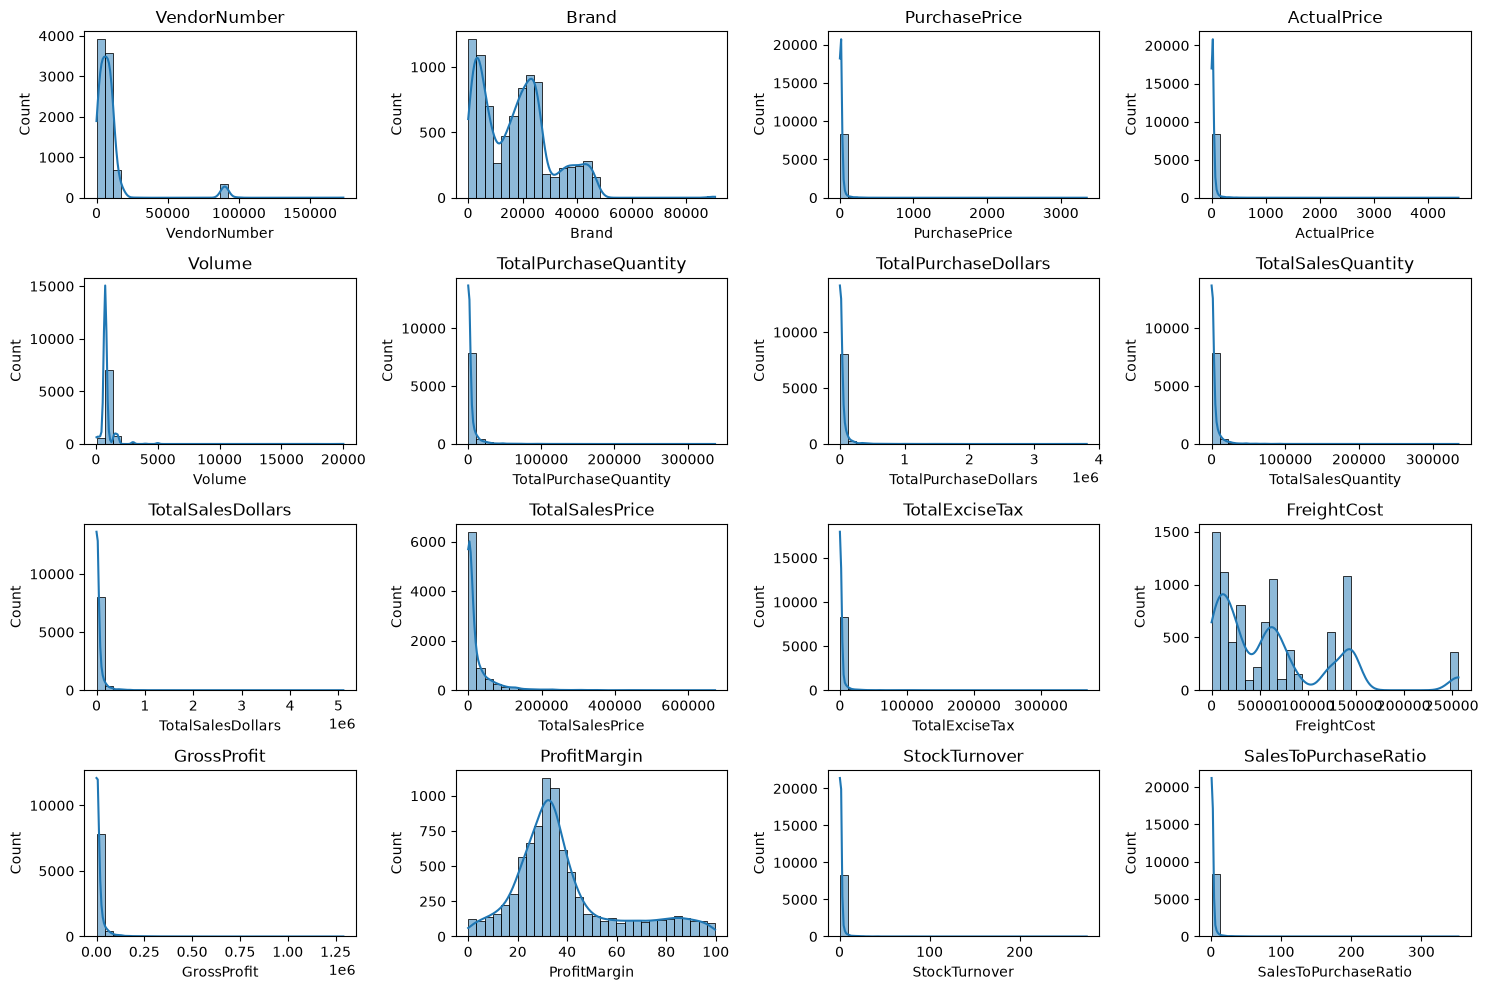

In [17]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

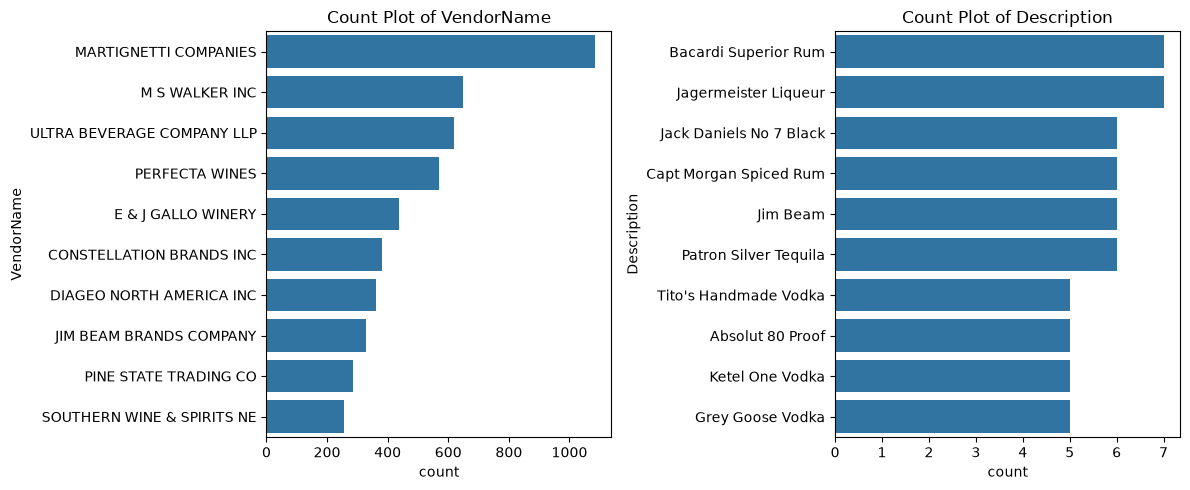

In [18]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

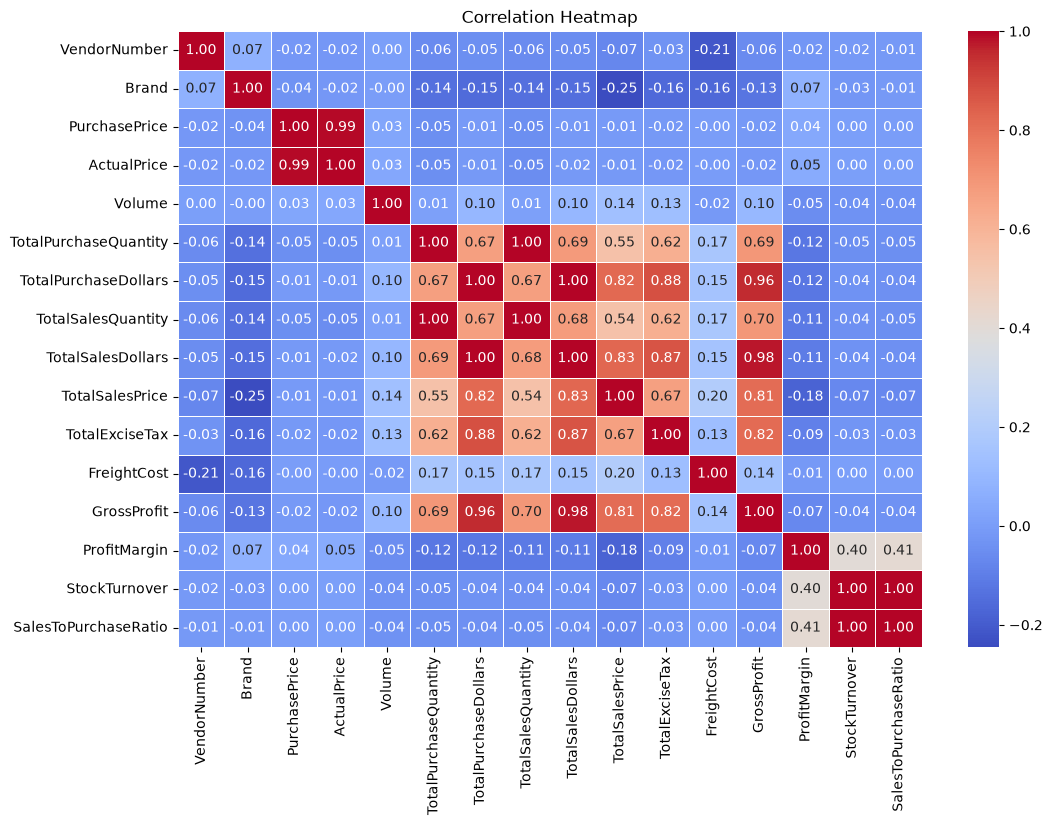

In [19]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Nhận định từ phân tích tương quan

- `PurchasePrice` có **mối tương quan rất yếu** với `TotalSalesDollars` (-0.012) và `GrossProfit` (-0.016). Điều này cho thấy sự thay đổi của giá mua gần như không có mối liên hệ tuyến tính đáng kể với doanh thu bán hàng hoặc lợi nhuận gộp trong bộ dữ liệu này.

- `TotalPurchaseQuantity` và `TotalSalesQuantity` có **mối tương quan dương rất mạnh** (0.999). Điều này cho thấy số lượng mua vào và số lượng bán ra biến động gần như đồng thời. Tuy nhiên, chỉ từ hệ số tương quan này chưa thể kết luận chắc chắn rằng hoạt động quản lý tồn kho là hiệu quả.

- `ProfitMargin` và `TotalSalesPrice` có **mối tương quan âm yếu** (-0.179), cho thấy khi tổng giá bán tăng thì biên lợi nhuận có xu hướng giảm nhẹ. Điều này có thể liên quan đến cơ cấu sản phẩm, mức chiết khấu, chi phí đầu vào hoặc áp lực cạnh tranh về giá.

- `StockTurnover` có mối tương quan âm rất yếu với cả `GrossProfit` (-0.038) và `ProfitMargin` (-0.055). Điều này cho thấy tốc độ luân chuyển hàng tồn kho cao hơn **không nhất thiết đi kèm với mức lợi nhuận hoặc biên lợi nhuận cao hơn**.

### Data Analysis

#### Xác định các thương hiệu cần điều chỉnh chương trình khuyến mãi hoặc chiến lược giá

Xác định những thương hiệu có **hiệu suất bán hàng thấp nhưng biên lợi nhuận cao**, vì đây có thể là các sản phẩm vẫn có khả năng sinh lời tốt nhưng chưa đạt được doanh số tương xứng.

Những thương hiệu này có thể cần được xem xét:

- Tăng cường các chương trình **khuyến mãi** để kích thích nhu cầu.
- Điều chỉnh **chiến lược giá** nhằm cải thiện sức cạnh tranh.
- Tăng mức độ hiện diện hoặc hỗ trợ bán hàng cho các sản phẩm có biên lợi nhuận tốt nhưng doanh số thấp.
- Đánh giá lại liệu mức giá hiện tại có đang hạn chế lượng tiêu thụ hay không.

In [20]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',  # Sales performance metric
    'ProfitMargin': 'mean'       # Average profit margin
}).reset_index()

brand_performance.sort_values('ProfitMargin')


,Description,TotalSalesDollars,ProfitMargin
5483,Pepperjack Barossa Red,191.92,0.02
2953,Flint & Steel Svgn Bl Napa V,119.92,0.03
2179,Croft Tawny Porto,191.84,0.04
2561,Douglass Hill Merlot,143.76,0.08
5383,Parducci 13 True Grit Chard,24927.81,0.12
...,...,...,...
4566,M Chiarlo Gavi Wh,1208.90,99.39
657,Beniotome Sesame Shochu,4768.41,99.53
6447,Skinnygirl Tangerine Vodka,2368.42,99.54
2411,DiSaronno Amaretto,4781.16,99.55


In [21]:
# threshold for "low sales" (bottom 15%) and "high margin" (top 15%)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6197,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6235,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5072,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6243,Sbragia Home Ranch Merlot,549.75,66.44


In [23]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

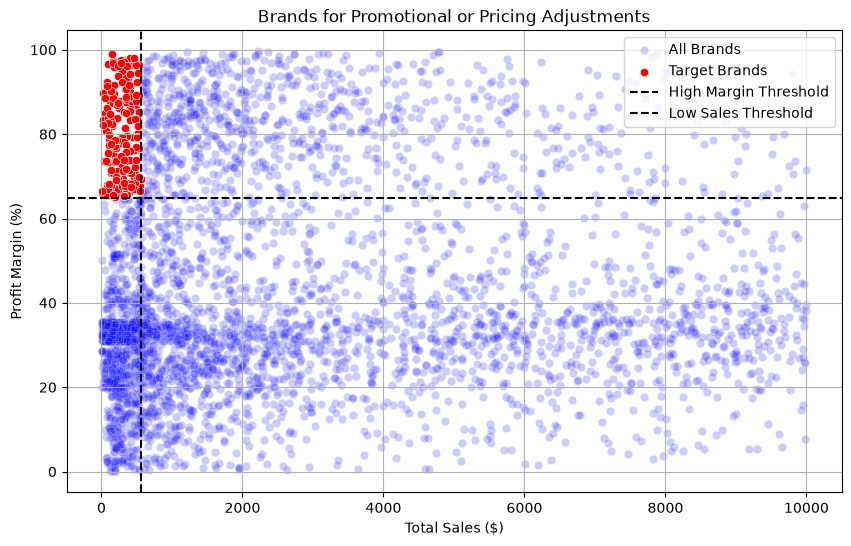

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#### Xác định các nhà cung cấp và thương hiệu có hiệu suất bán hàng cao nhất

In [25]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [26]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16456111.43
M S WALKER INC                14679529.55
Name: TotalSalesDollars, dtype: float64

In [27]:
top_vendors.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.46M
M S WALKER INC                14.68M
Name: TotalSalesDollars, dtype: str

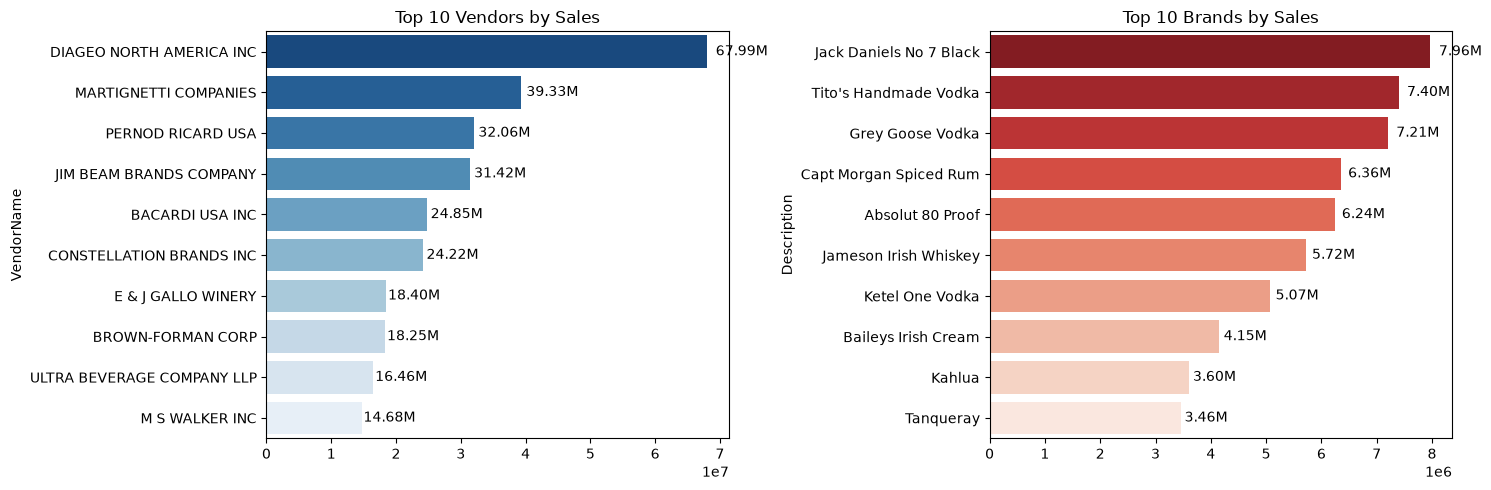

In [28]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### Nhà cung cấp nào đóng góp nhiều nhất vào tổng giá trị mua hàng?

In [29]:
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars":"sum"
}).reset_index()

# Calculate Contribution % to Overall Procurement
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()) * 100

# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseDollars", ascending=False),2)

# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.34
56,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.32
67,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.78
45,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.66
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.69
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.98
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.32
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.94
105,ULTRA BEVERAGE COMPANY LLP,11.13M,5.33M,16.46M,3.63
52,M S WALKER INC,9.75M,4.93M,14.68M,3.18


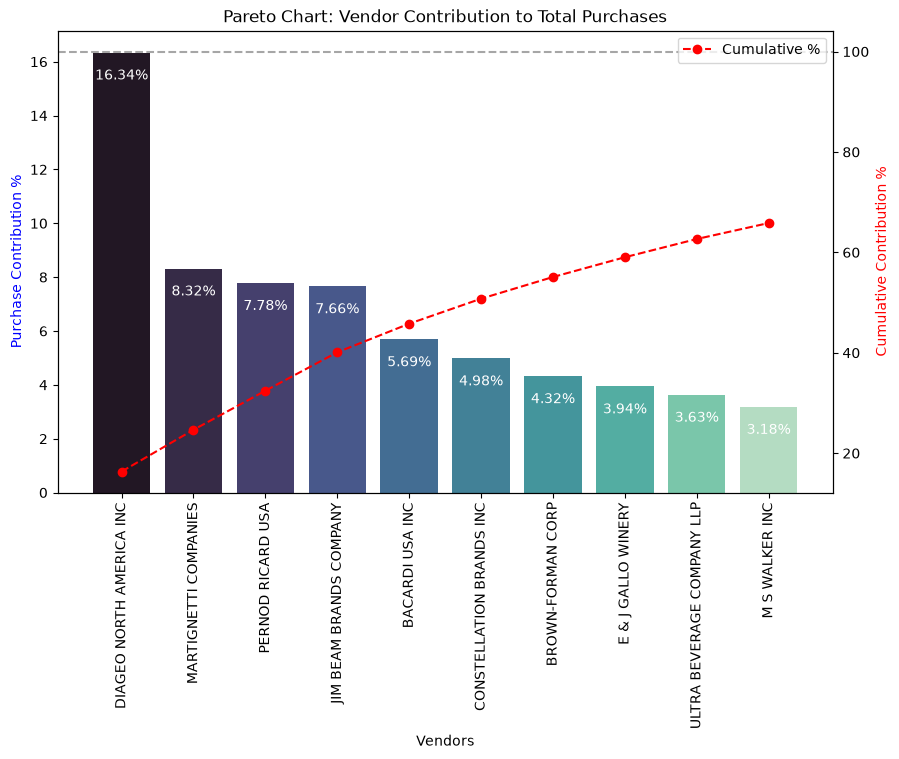

In [30]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'],  palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

### Tổng giá trị mua hàng phụ thuộc vào các nhà cung cấp hàng đầu ở mức độ nào?

Total Purchase Contribution of top 10 vendors is 65.84 %


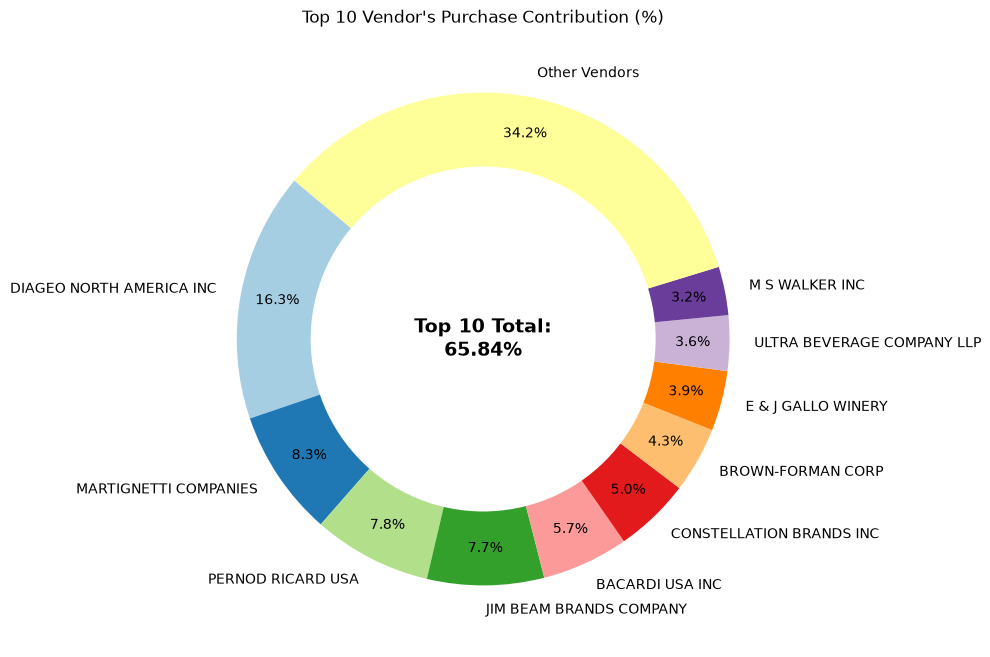

In [31]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

- Các nhà cung cấp còn lại chỉ đóng góp **34,31%** tổng giá trị mua hàng, cho thấy mức độ sử dụng của nhóm này còn tương đối thấp hoặc họ có thể chưa đủ sức cạnh tranh so với các nhà cung cấp hàng đầu.

- Nếu mức độ phụ thuộc vào một số ít nhà cung cấp quá cao, doanh nghiệp nên cân nhắc **tìm kiếm và phát triển thêm các nhà cung cấp mới** nhằm đa dạng hóa nguồn cung và giảm thiểu rủi ro phụ thuộc.

#### Việc mua hàng với số lượng lớn có giúp giảm đơn giá hay không, và khối lượng mua tối ưu để tiết kiệm chi phí là bao nhiêu?

In [32]:
# Calculate Unit Purchase Price per Vendor & Volume Group
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

# Group by Order Sizes (e.g., Small, Medium, Large Purchases)
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

# Analyze Cost Savings per Order Size
bulk_purchase_analysis = df.groupby("OrderSize")["UnitPurchasePrice"].mean().reset_index()
print(bulk_purchase_analysis)


  OrderSize  UnitPurchasePrice
0     Small          39.128653
1    Medium          15.489374
2     Large          10.776200


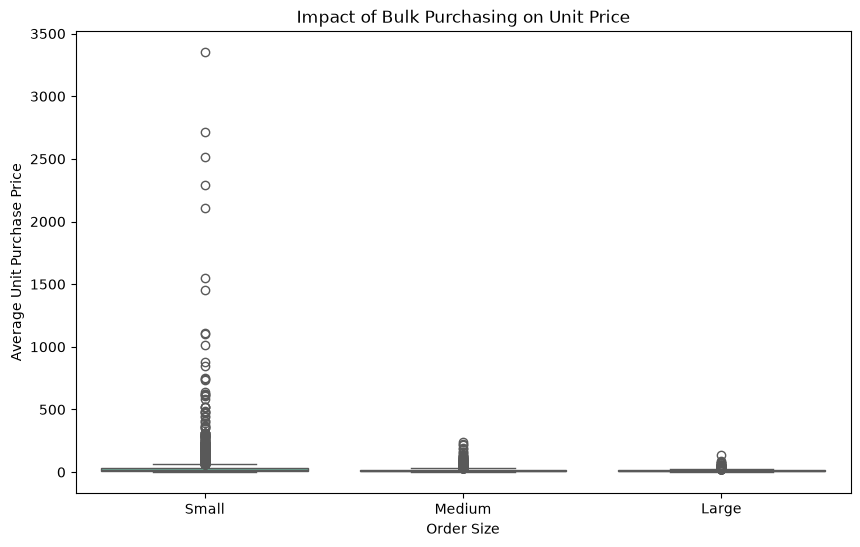

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


- Các nhà cung cấp mua hàng với **số lượng lớn (Large Order Size)** nhận được **đơn giá thấp nhất, khoảng 10,78 USD/đơn vị**. Điều này có thể giúp cải thiện biên lợi nhuận nếu doanh nghiệp quản lý hàng tồn kho hiệu quả.

- Chênh lệch đơn giá giữa nhóm đơn hàng nhỏ (`Small`) và đơn hàng lớn (`Large`) là đáng kể, tương ứng với mức **giảm khoảng 72% chi phí trên mỗi đơn vị**.

- Kết quả này cho thấy chiến lược **định giá theo số lượng (bulk pricing)** có thể khuyến khích các nhà cung cấp mua với khối lượng lớn hơn. Việc này có thể làm tăng tổng giá trị hoặc sản lượng mua hàng, mặc dù doanh thu hoặc giá bán trên mỗi đơn vị thấp hơn.

#### Nhà cung cấp nào có vòng quay hàng tồn kho thấp, cho thấy tình trạng tồn kho dư thừa và sản phẩm bán chậm?

In [35]:
# Identify Low Inventory Turnover Vendors
low_turnover_vendors = df[df["StockTurnover"] < 1].groupby("VendorName")["StockTurnover"].mean().reset_index()

# Sort by Lowest Turnover
low_turnover_vendors = low_turnover_vendors.sort_values(by="StockTurnover", ascending=True)
low_turnover_vendors.head(10)


,VendorName,StockTurnover
0,ALISA CARR BEVERAGES,0.620000
36,HIGHLAND WINE MERCHANTS LLC,0.710000
60,PARK STREET IMPORTS LLC,0.750000
19,Circa Wines,0.755385
41,KLIN SPIRITS LLC,0.760000
26,Dunn Wine Brokers,0.767500
15,CENTEUR IMPORTS LLC,0.772500
78,SMOKY QUARTZ DISTILLERY LLC,0.780000
90,TAMWORTH DISTILLING,0.800000
91,THE IMPORTED GRAPE LLC,0.808182


- Hàng tồn kho bán chậm làm gia tăng **chi phí lưu kho**, bao gồm chi phí thuê kho, bảo hiểm, hao mòn và khấu hao hàng tồn kho.
- Việc xác định các nhà cung cấp có **vòng quay hàng tồn kho thấp** là rất quan trọng để cải thiện hiệu quả hoạt động, giảm chi phí và nâng cao khả năng sinh lời của doanh nghiệp.

#### Có bao nhiêu vốn đang bị “giam” trong hàng tồn kho chưa bán theo từng nhà cung cấp, và những nhà cung cấp nào đóng góp nhiều nhất vào lượng vốn tồn đọng này?

In [36]:
# Calculate Unsold Inventory Value
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

Total Unsold Capital: 2.69M


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
45,JIM BEAM BRANDS COMPANY,554.67K
67,PERNOD RICARD USA,470.63K
115,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
11,BROWN-FORMAN CORP,177.73K
78,SAZERAC CO INC,173.03K
20,CONSTELLATION BRANDS INC,133.62K
60,MOET HENNESSY USA INC,126.48K
76,REMY COINTREAU USA INC,118.60K


#### Khoảng tin cậy 95% cho biên lợi nhuận của nhóm nhà cung cấp có hiệu suất cao và nhóm nhà cung cấp có hiệu suất thấp là bao nhiêu?

Top Vendors 95% CI: (30.73, 31.60), Mean: 31.17
Low Vendors 95% CI: (40.46, 42.60), Mean: 41.53


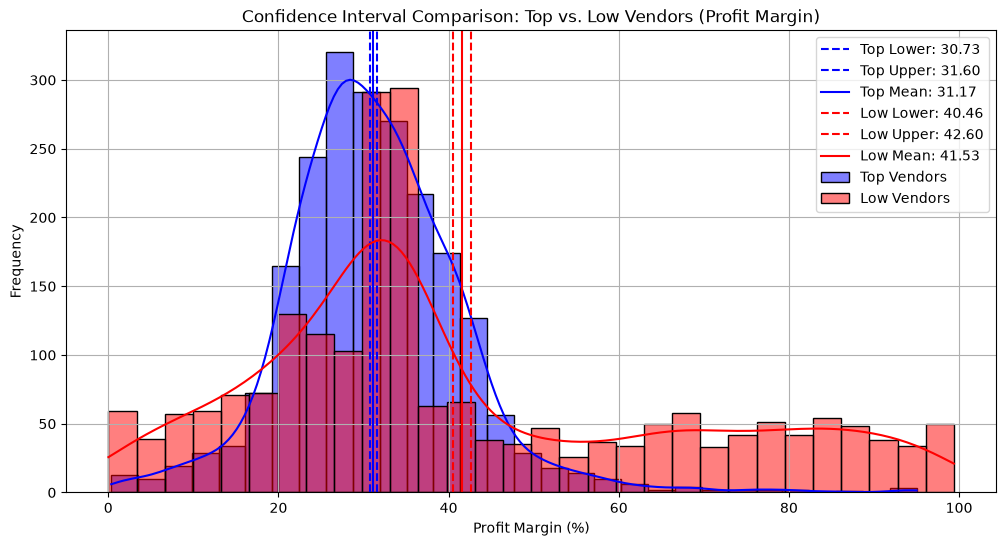

In [37]:
# Define top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


- Khoảng tin cậy 95% của **nhóm nhà cung cấp có hiệu suất thấp** dao động từ **40,48% đến 42,62%**, cao hơn đáng kể so với khoảng **30,74% đến 31,61%** của nhóm nhà cung cấp có hiệu suất cao.

- Kết quả này cho thấy các nhà cung cấp có doanh số thấp hơn có xu hướng duy trì **biên lợi nhuận cao hơn**. Nguyên nhân có thể đến từ việc áp dụng mức giá cao hơn, cơ cấu sản phẩm khác biệt hoặc chi phí vận hành thấp hơn.

- **Đối với nhóm nhà cung cấp có hiệu suất cao:** nếu mục tiêu là cải thiện khả năng sinh lời, doanh nghiệp có thể xem xét điều chỉnh giá có chọn lọc, tối ưu chi phí hoặc áp dụng các chiến lược bán theo gói (`bundling`).

- **Đối với nhóm nhà cung cấp có hiệu suất thấp:** mặc dù biên lợi nhuận cao hơn, doanh số thấp có thể cho thấy nhu cầu cải thiện hoạt động marketing, điều chỉnh mức giá cạnh tranh hơn hoặc nâng cao hiệu quả phân phối.

#### Có sự khác biệt có ý nghĩa thống kê về biên lợi nhuận giữa nhóm nhà cung cấp có hiệu suất cao và nhóm nhà cung cấp có hiệu suất thấp hay không?

### Giả thuyết kiểm định

- **H₀ (Giả thuyết không - Null Hypothesis):** Không có sự khác biệt có ý nghĩa thống kê về **biên lợi nhuận trung bình** giữa nhóm nhà cung cấp có hiệu suất cao và nhóm nhà cung cấp có hiệu suất thấp.

- **H₁ (Giả thuyết đối - Alternative Hypothesis):** Có sự khác biệt có ý nghĩa thống kê về **biên lợi nhuận trung bình** giữa nhóm nhà cung cấp có hiệu suất cao và nhóm nhà cung cấp có hiệu suất thấp.

In [38]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6188, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


- Giá trị `p-value` rất nhỏ cho thấy sự khác biệt về biên lợi nhuận giữa hai nhóm nhà cung cấp là **có ý nghĩa thống kê**.

- Tuy nhiên, `p-value` nhỏ **không tự động chứng minh** rằng mức chênh lệch đó có ý nghĩa thực tiễn. Để đánh giá ý nghĩa kinh doanh, cần xem thêm quy mô chênh lệch, khoảng tin cậy và có thể cả **effect size**.

- Kết quả cho thấy hai nhóm nhà cung cấp có đặc điểm sinh lời khác nhau rõ rệt. Nhóm có hiệu suất bán hàng cao và nhóm có hiệu suất thấp có thể đang vận hành với **cơ cấu giá, chi phí và biên lợi nhuận khác nhau**.